In [1]:
import pandas as pd
import numpy as np

po    = pd.read_csv("playoff_toi.csv")
types = pd.read_csv("player_types.csv")
team  = pd.read_csv("team.csv")

# Make the Physical labels unique by position
types.loc[(types["type"] == "Physical") & (types["pos_group"] == "F"), "type"] = "Physical F"
types.loc[(types["type"] == "Physical") & (types["pos_group"] == "D"), "type"] = "Physical D"

# Attach each playoff player's type from his feature season
po["feat_season"] = po["feat_season"].astype(int)
po_t = po.merge(types[["playerId", "seasonId", "pos_group", "type"]]
                  .rename(columns={"seasonId": "feat_season"}),
                on=["playerId", "feat_season"], how="left")
print("Playoff rows without a type:", int(po_t["type"].isna().sum()))

# Share of each team's playoff ice time, within position
toi = po_t.groupby(["seasonId", "teamAbbrevs", "pos_group", "type"])["timeOnIce"].sum()
share = (toi / toi.groupby(level=[0, 1, 2]).transform("sum")).rename("share").reset_index()
comp = share.pivot_table(index=["seasonId", "teamAbbrevs"], columns="type",
                         values="share", fill_value=0).reset_index()

# Join with team data (this also drops the 2019-20 qualifying-round losers)
data = team.merge(comp, left_on=["seasonId", "triCode"],
                  right_on=["seasonId", "teamAbbrevs"], how="inner")

f_types = ["Top-line scorer", "Skilled playmaker", "Power forward", "Defensive/PK", "Physical F"]
d_types = ["Offensive", "Shutdown/PK", "Two-way/depth", "Physical D"]
print("Team-seasons:", len(data))
print("Forward shares sum to 1:", np.allclose(data[f_types].sum(axis=1), 1))
print("Defense shares sum to 1:", np.allclose(data[d_types].sum(axis=1), 1), "\n")
print(data[f_types + d_types].describe().loc[["mean", "min", "max"]].round(3))

data.to_csv("analysis_data.csv", index=False)

Playoff rows without a type: 0
Team-seasons: 336
Forward shares sum to 1: True
Defense shares sum to 1: True 

      Top-line scorer  Skilled playmaker  Power forward  Defensive/PK  \
mean            0.349              0.266          0.157         0.197   
min             0.000              0.000          0.000         0.000   
max             0.718              0.696          0.565         0.430   

      Physical F  Offensive  Shutdown/PK  Two-way/depth  Physical D  
mean       0.030      0.355        0.300          0.236       0.108  
min        0.000      0.000        0.000          0.000       0.000  
max        0.173      0.746        0.686          0.860       0.493  


In [2]:
by_round = data.groupby("rounds_won")[["pointPct", "save_pct"] + f_types + d_types].mean().round(3)
by_round.insert(0, "n_teams", data["rounds_won"].value_counts().sort_index())
by_round.index = ["Lost 1st round", "Lost 2nd round", "Lost conf. final", "Lost Final", "Won Cup"]
display(by_round.T)

,Lost 1st round,Lost 2nd round,Lost conf. final,Lost Final,Won Cup
n_teams,168.000,84.000,42.000,21.000,21.000
pointPct,0.613,0.638,0.645,0.617,0.658
save_pct,0.908,0.910,0.910,0.906,0.911
Top-line scorer,0.330,0.360,0.367,0.369,0.405
Skilled playmaker,0.267,0.273,0.283,0.236,0.236
Power forward,0.171,0.142,0.147,0.166,0.120
Defensive/PK,0.198,0.199,0.178,0.205,0.216
Physical F,0.035,0.026,0.025,0.025,0.023
Offensive,0.335,0.363,0.369,0.403,0.409
Shutdown/PK,0.305,0.282,0.348,0.241,0.298


In [3]:
import statsmodels.formula.api as smf

rename = {"Top-line scorer": "f_topline", "Skilled playmaker": "f_playmaker",
          "Power forward": "f_power", "Defensive/PK": "f_defensive", "Physical F": "f_physical",
          "Offensive": "d_offensive", "Shutdown/PK": "d_shutdown",
          "Two-way/depth": "d_twoway", "Physical D": "d_physical"}
rd = data.rename(columns=rename).copy()
rd[list(rename.values())] = rd[list(rename.values())] * 10   # 1 unit = 10 percentage points of ice time
rd["pointPct"] = rd["pointPct"] * 100                        # 1 unit = 1 point of points %
rd["save_pct"] = rd["save_pct"] * 100                        # 1 unit = 1 point of save %

shares = ["f_topline", "f_playmaker", "f_power", "f_physical",   # baseline: f_defensive (left out)
          "d_offensive", "d_shutdown", "d_physical"]             # baseline: d_twoway (left out)
formula = "rounds_won ~ " + " + ".join(shares) + " + pointPct + save_pct + C(seasonId)"

ols = smf.ols(formula, data=rd).fit(cov_type="HC1")   # robust standard errors

key = shares + ["pointPct", "save_pct"]
ci = ols.conf_int()
out = pd.DataFrame({"coef": ols.params[key], "std_err": ols.bse[key], "p_value": ols.pvalues[key],
                    "ci_low": ci.loc[key, 0], "ci_high": ci.loc[key, 1]}).round(3)

print("n =", int(ols.nobs), "| R-squared:", round(ols.rsquared, 3))
joint = ols.f_test(", ".join(f"{v} = 0" for v in shares))
print("Joint test, all 7 composition variables = 0:  F =", round(float(joint.fvalue), 2),
      "| p =", round(float(joint.pvalue), 4), "\n")
display(out)

n = 336 | R-squared: 0.091
Joint test, all 7 composition variables = 0:  F = 1.54 | p = 0.1522 



,coef,std_err,p_value,ci_low,ci_high
f_topline,0.054,0.098,0.584,-0.139,0.246
f_playmaker,0.014,0.089,0.878,-0.161,0.189
f_power,-0.078,0.092,0.397,-0.258,0.102
f_physical,-0.336,0.194,0.084,-0.717,0.045
d_offensive,0.101,0.048,0.037,0.006,0.195
d_shutdown,0.036,0.051,0.479,-0.064,0.135
d_physical,-0.019,0.070,0.789,-0.155,0.118
pointPct,0.046,0.018,0.013,0.010,0.082
save_pct,0.004,0.101,0.969,-0.193,0.201


In [4]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

X = rd[key].join(pd.get_dummies(rd["seasonId"], prefix="s", drop_first=True, dtype=float))
ologit = OrderedModel(rd["rounds_won"], X, distr="logit").fit(method="bfgs", maxiter=2000, disp=False)

print("Converged:", ologit.mle_retvals["converged"], "\n")
out2 = pd.DataFrame({"ologit_coef": ologit.params[key],
                     "odds_ratio": np.exp(ologit.params[key]),
                     "ologit_p": ologit.pvalues[key],
                     "ols_coef": out["coef"],
                     "ols_p": out["p_value"]}).round(3)
display(out2)

Converged: True 



,ologit_coef,odds_ratio,ologit_p,ols_coef,ols_p
f_topline,0.141,1.151,0.373,0.054,0.584
f_playmaker,0.112,1.119,0.434,0.014,0.878
f_power,-0.102,0.903,0.491,-0.078,0.397
f_physical,-0.729,0.482,0.029,-0.336,0.084
d_offensive,0.177,1.193,0.026,0.101,0.037
d_shutdown,0.084,1.088,0.291,0.036,0.479
d_physical,-0.014,0.986,0.901,-0.019,0.789
pointPct,0.087,1.091,0.001,0.046,0.013
save_pct,0.046,1.047,0.766,0.004,0.969


In [5]:
def run_both(df):
    o = smf.ols(formula, data=df).fit(cov_type="HC1")
    Xr = df[key].join(pd.get_dummies(df["seasonId"], prefix="s", drop_first=True, dtype=float))
    l = OrderedModel(df["rounds_won"], Xr, distr="logit").fit(method="bfgs", maxiter=2000, disp=False)
    joint_p = float(o.f_test(", ".join(f"{v} = 0" for v in shares)).pvalue)
    tab = pd.DataFrame({"ols_coef": o.params[key], "ols_p": o.pvalues[key],
                        "ologit_OR": np.exp(l.params[key]), "ologit_p": l.pvalues[key]}).round(3)
    return tab, int(o.nobs), joint_p, l.mle_retvals["converged"]

keep = ~rd["seasonId"].isin([20122013, 20192020, 20202021])
tab_r1, n_r1, joint_r1, conv_r1 = run_both(rd[keep])
print("Robustness 1 (drop 2012-13, 2019-20, 2020-21) | n =", n_r1,
      "| joint p =", round(joint_r1, 4), "| ologit converged:", conv_r1)
display(tab_r1)

Robustness 1 (drop 2012-13, 2019-20, 2020-21) | n = 288 | joint p = 0.1699 | ologit converged: True


,ols_coef,ols_p,ologit_OR,ologit_p
f_topline,0.110,0.289,1.220,0.246
f_playmaker,0.042,0.665,1.164,0.323
f_power,-0.055,0.580,0.936,0.677
f_physical,-0.305,0.180,0.457,0.044
d_offensive,0.088,0.084,1.183,0.047
d_shutdown,-0.006,0.913,1.005,0.953
d_physical,-0.079,0.271,0.912,0.439
pointPct,0.043,0.048,1.097,0.004
save_pct,-0.054,0.640,0.905,0.562


In [6]:
# Expected ice time: regular-season TOI per game x playoff games played
reg_raw = pd.read_csv("regular_season_raw.csv")
reg_raw["rs_toi_pg"] = reg_raw["timeOnIce"] / reg_raw["gamesPlayed"]
po_t2 = po_t.merge(reg_raw[["playerId", "seasonId", "rs_toi_pg"]]
                     .rename(columns={"seasonId": "feat_season"}),
                   on=["playerId", "feat_season"], how="left")
print("Players missing regular-season TOI per game:", int(po_t2["rs_toi_pg"].isna().sum()))
po_t2["exp_toi"] = po_t2["rs_toi_pg"] * po_t2["gamesPlayed"]

# Same composition steps as before, with expected ice time
toi2 = po_t2.groupby(["seasonId", "teamAbbrevs", "pos_group", "type"])["exp_toi"].sum()
share2 = (toi2 / toi2.groupby(level=[0, 1, 2]).transform("sum")).rename("share").reset_index()
comp2 = share2.pivot_table(index=["seasonId", "teamAbbrevs"], columns="type",
                           values="share", fill_value=0).reset_index()
data2 = team.merge(comp2, left_on=["seasonId", "triCode"],
                   right_on=["seasonId", "teamAbbrevs"], how="inner")

rd2 = data2.rename(columns=rename).copy()
rd2[list(rename.values())] = rd2[list(rename.values())] * 10
rd2["pointPct"] = rd2["pointPct"] * 100
rd2["save_pct"] = rd2["save_pct"] * 100
print("Team-seasons:", len(rd2), "\n")

# Diagnostic 1: how similar are the two versions of each share?
print("Correlation, playoff TOI shares vs. expected TOI shares:")
print(pd.Series({v: np.corrcoef(rd[v], rd2[v])[0, 1] for v in shares}).round(3), "\n")

# Diagnostic 2: did deeper teams shift playoff minutes toward these types?
# (actual minus expected share, in percentage points)
print("Actual minus expected share, by rounds won (percentage points):")
print(((rd[["f_topline", "d_offensive", "f_physical"]] - rd2[["f_topline", "d_offensive", "f_physical"]]) * 10)
      .groupby(rd["rounds_won"]).mean().round(2), "\n")

tab_r2, n_r2, joint_r2, conv_r2 = run_both(rd2)
print("Robustness 2 (expected ice time weights) | n =", n_r2,
      "| joint p =", round(joint_r2, 4), "| ologit converged:", conv_r2)
display(tab_r2)

Players missing regular-season TOI per game: 0
Team-seasons: 336 

Correlation, playoff TOI shares vs. expected TOI shares:
f_topline      0.994
f_playmaker    0.994
f_power        0.990
f_physical     0.978
d_offensive    0.991
d_shutdown     0.992
d_physical     0.991
dtype: float64 

Actual minus expected share, by rounds won (percentage points):
            f_topline  d_offensive  f_physical
rounds_won                                    
0                0.84         0.88       -0.29
1                0.81         0.91       -0.29
2                0.80         0.49       -0.14
3                0.68         0.75       -0.27
4                1.10         0.41       -0.12 

Robustness 2 (expected ice time weights) | n = 336 | joint p = 0.065 | ologit converged: True


,ols_coef,ols_p,ologit_OR,ologit_p
f_topline,0.102,0.316,1.266,0.149
f_playmaker,0.056,0.540,1.214,0.187
f_power,-0.053,0.563,0.939,0.677
f_physical,-0.346,0.060,0.473,0.019
d_offensive,0.115,0.018,1.222,0.013
d_shutdown,0.035,0.475,1.087,0.301
d_physical,-0.013,0.846,1.001,0.991
pointPct,0.043,0.017,1.086,0.002
save_pct,0.015,0.878,1.073,0.654


In [7]:
import os
os.makedirs("paper_outputs", exist_ok=True)

labels = {"rounds_won": "Playoff rounds won (0–4)",
          "pointPct": "Regular-season points %",
          "save_pct": "Regular-season save %",
          "Top-line scorer": "F: Top-line scorer (%)", "Skilled playmaker": "F: Skilled playmaker (%)",
          "Power forward": "F: Power forward (%)", "Defensive/PK": "F: Defensive/PK (%)",
          "Physical F": "F: Physical (%)",
          "Offensive": "D: Offensive (%)", "Shutdown/PK": "D: Shutdown/PK (%)",
          "Two-way/depth": "D: Two-way/depth (%)", "Physical D": "D: Physical (%)"}

t3 = data[list(labels)].copy()
t3[f_types + d_types] = t3[f_types + d_types] * 100
table3 = t3.agg(["mean", "std", "min", "max"]).T
table3.columns = ["Mean", "SD", "Min", "Max"]
table3.index = [labels[c] for c in table3.index]
table3 = table3.round(3)
table3.loc[[labels[c] for c in f_types + d_types]] = table3.loc[[labels[c] for c in f_types + d_types]].round(1)

table3.to_csv("paper_outputs/table3_summary_stats.csv")
display(table3)

,Mean,SD,Min,Max
Playoff rounds won (0–4),0.938,1.199,0.000,4.000
Regular-season points %,0.626,0.050,0.500,0.823
Regular-season save %,0.909,0.010,0.876,0.933
F: Top-line scorer (%),34.900,13.100,0.000,71.800
F: Skilled playmaker (%),26.600,13.000,0.000,69.600
F: Power forward (%),15.700,9.800,0.000,56.500
F: Defensive/PK (%),19.700,8.600,0.000,43.000
F: Physical (%),3.000,3.600,0.000,17.300
D: Offensive (%),35.500,15.500,0.000,74.600
D: Shutdown/PK (%),30.000,16.100,0.000,68.600


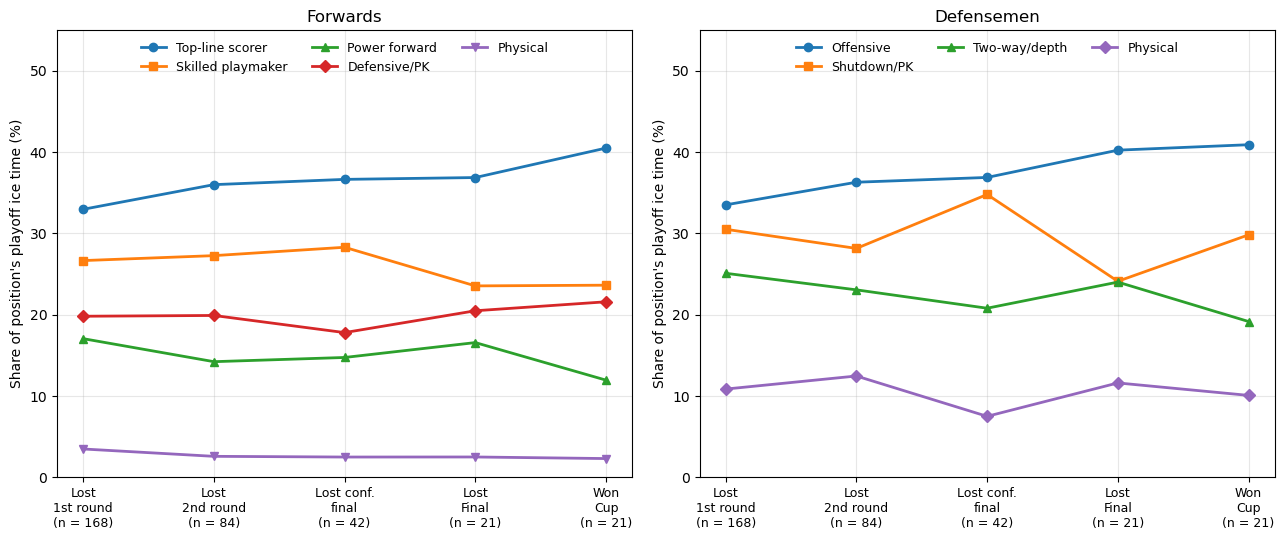

In [8]:
import matplotlib.pyplot as plt

groups = ["Lost\n1st round", "Lost\n2nd round", "Lost conf.\nfinal", "Lost\nFinal", "Won\nCup"]
means = data.groupby("rounds_won")[f_types + d_types].mean() * 100
ns = data["rounds_won"].value_counts().sort_index()
xlabels = [f"{g}\n(n = {n})" for g, n in zip(groups, ns)]

colors = {"Top-line scorer": "#1f77b4", "Skilled playmaker": "#ff7f0e", "Power forward": "#2ca02c",
          "Defensive/PK": "#d62728", "Physical F": "#9467bd",
          "Offensive": "#1f77b4", "Shutdown/PK": "#ff7f0e", "Two-way/depth": "#2ca02c",
          "Physical D": "#9467bd"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, types_, title in [(axes[0], f_types, "Forwards"), (axes[1], d_types, "Defensemen")]:
    for t, marker in zip(types_, ["o", "s", "^", "D", "v"]):
        ax.plot(range(5), means[t], marker=marker, linewidth=2, color=colors[t],
                label=t.replace("Physical F", "Physical").replace("Physical D", "Physical"))
    ax.set_xticks(range(5))
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_ylim(0, 55)
    ax.set_ylabel("Share of position's playoff ice time (%)")
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=9, loc="upper center", ncol=3)

plt.tight_layout()
plt.savefig("paper_outputs/figure2_composition_by_finish.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
names = {"f_topline": "F: Top-line scorer", "f_playmaker": "F: Skilled playmaker",
         "f_power": "F: Power forward", "f_physical": "F: Physical",
         "d_offensive": "D: Offensive", "d_shutdown": "D: Shutdown/PK", "d_physical": "D: Physical",
         "pointPct": "Regular-season points %", "save_pct": "Regular-season save %"}

def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

ci = ols.conf_int()
table4 = pd.DataFrame({
    "OLS coef. (SE)":      [f"{ols.params[v]:.3f}{stars(ols.pvalues[v])} ({ols.bse[v]:.3f})" for v in key],
    "OLS 95% CI":          [f"[{ci.loc[v, 0]:.3f}, {ci.loc[v, 1]:.3f}]" for v in key],
    "Ordered logit OR":    [f"{np.exp(ologit.params[v]):.3f}{stars(ologit.pvalues[v])}" for v in key],
    "Ordered logit p":     [f"{ologit.pvalues[v]:.3f}" for v in key],
}, index=[names[v] for v in key])

bottom = pd.DataFrame({
    "OLS coef. (SE)":   ["Yes", "336", f"{ols.rsquared:.3f}", f"{float(joint.pvalue):.3f}"],
    "OLS 95% CI":       ["", "", "", ""],
    "Ordered logit OR": ["Yes", "336", "", ""],
    "Ordered logit p":  ["", "", "", ""],
}, index=["Season effects", "Observations", "R-squared", "Joint test, 7 composition variables (p)"])

table4 = pd.concat([table4, bottom])
table4.index.name = "Variable"
table4.to_csv("paper_outputs/table4_main_regression.csv")
display(table4)

,OLS coef. (SE),OLS 95% CI,Ordered logit OR,Ordered logit p
Variable,,,,
F: Top-line scorer,0.054 (0.098),"[-0.139, 0.246]",1.151,0.373
F: Skilled playmaker,0.014 (0.089),"[-0.161, 0.189]",1.119,0.434
F: Power forward,-0.078 (0.092),"[-0.258, 0.102]",0.903,0.491
F: Physical,-0.336* (0.194),"[-0.717, 0.045]",0.482**,0.029
D: Offensive,0.101** (0.048),"[0.006, 0.195]",1.193**,0.026
D: Shutdown/PK,0.036 (0.051),"[-0.064, 0.135]",1.088,0.291
D: Physical,-0.019 (0.070),"[-0.155, 0.118]",0.986,0.901
Regular-season points %,0.046** (0.018),"[0.010, 0.082]",1.091***,0.001
Regular-season save %,0.004 (0.101),"[-0.193, 0.201]",1.047,0.766


In [10]:
specs = [("Main", rd),
         ("Drop 2012-13, 2019-20, 2020-21", rd[keep]),
         ("Expected ice time weights", rd2)]

cols, n_row, joint_row = {}, {}, {}
for label, df in specs:
    tab, n, jp, conv = run_both(df)
    cols[f"{label}: OLS coef."] = [f"{tab.loc[v, 'ols_coef']:.3f}{stars(tab.loc[v, 'ols_p'])}" for v in key]
    cols[f"{label}: Ordered logit OR"] = [f"{tab.loc[v, 'ologit_OR']:.3f}{stars(tab.loc[v, 'ologit_p'])}" for v in key]
    n_row[f"{label}: OLS coef."] = n_row[f"{label}: Ordered logit OR"] = str(n)
    joint_row[f"{label}: OLS coef."] = f"{jp:.3f}"
    joint_row[f"{label}: Ordered logit OR"] = ""
    print(label, "| ordered logit converged:", conv)

table5 = pd.DataFrame(cols, index=[names[v] for v in key])
table5.loc["Observations"] = n_row
table5.loc["Joint test, 7 composition variables (p)"] = joint_row
table5.index.name = "Variable"
table5.to_csv("paper_outputs/table5_robustness.csv")
display(table5)

Main | ordered logit converged: True
Drop 2012-13, 2019-20, 2020-21 | ordered logit converged: True
Expected ice time weights | ordered logit converged: True


,Main: OLS coef.,Main: Ordered logit OR,"Drop 2012-13, 2019-20, 2020-21: OLS coef.","Drop 2012-13, 2019-20, 2020-21: Ordered logit OR",Expected ice time weights: OLS coef.,Expected ice time weights: Ordered logit OR
Variable,,,,,,
F: Top-line scorer,0.054,1.151,0.110,1.220,0.102,1.266
F: Skilled playmaker,0.014,1.119,0.042,1.164,0.056,1.214
F: Power forward,-0.078,0.903,-0.055,0.936,-0.053,0.939
F: Physical,-0.336*,0.482**,-0.305,0.457**,-0.346*,0.473**
D: Offensive,0.101**,1.193**,0.088*,1.183**,0.115**,1.222**
D: Shutdown/PK,0.036,1.088,-0.006,1.005,0.035,1.087
D: Physical,-0.019,0.986,-0.079,0.912,-0.013,1.001
Regular-season points %,0.046**,1.091***,0.043**,1.097***,0.043**,1.086***
Regular-season save %,0.004,1.047,-0.054,0.905,0.015,1.073


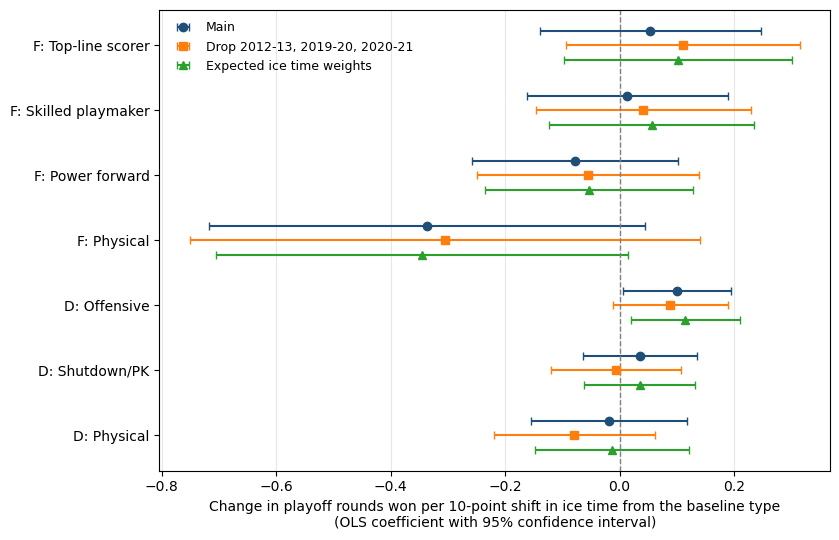

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ypos = np.arange(len(shares))[::-1]

for i, ((label, df), color, marker) in enumerate(zip(specs, ["#1f4e79", "#ff7f0e", "#2ca02c"], ["o", "s", "^"])):
    o = smf.ols(formula, data=df).fit(cov_type="HC1")
    b, c = o.params[shares].to_numpy(), o.conf_int().loc[shares].to_numpy()
    ax.errorbar(b, ypos + (1 - i) * 0.22, xerr=[b - c[:, 0], c[:, 1] - b],
                fmt=marker, color=color, capsize=3, markersize=6, label=label)

ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(ypos)
ax.set_yticklabels([names[v] for v in shares])
ax.set_xlabel("Change in playoff rounds won per 10-point shift in ice time from the baseline type\n"
              "(OLS coefficient with 95% confidence interval)")
ax.grid(axis="x", alpha=0.3)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("paper_outputs/figure3_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()